<a href="https://colab.research.google.com/github/heshamdahy/student-performance-factors-ml/blob/main/student_performance_factors_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


student=pd.read_csv('StudentPerformanceFactors.csv')

student.head()






,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
student.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [ ]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
cols_object=list(student.select_dtypes('object'))
cols_nan=[]
for col in cols_object:
    print(f' {col} ===> {student[col].unique()}',end='\n')
    if student[col].isnull().sum()>0:
      cols_nan.append(col)
    print(f'{col} ===>  {student[col].isnull().sum() }', end='\n')

for col in cols_nan:
   student.fillna({col:student[col].mode()[0]},inplace=True)


 Parental_Involvement ===> ['Low' 'Medium' 'High']
Parental_Involvement ===>  0
 Access_to_Resources ===> ['High' 'Medium' 'Low']
Access_to_Resources ===>  0
 Extracurricular_Activities ===> ['No' 'Yes']
Extracurricular_Activities ===>  0
 Motivation_Level ===> ['Low' 'Medium' 'High']
Motivation_Level ===>  0
 Internet_Access ===> ['Yes' 'No']
Internet_Access ===>  0
 Family_Income ===> ['Low' 'Medium' 'High']
Family_Income ===>  0
 Teacher_Quality ===> ['Medium' 'High' 'Low' nan]
Teacher_Quality ===>  78
 School_Type ===> ['Public' 'Private']
School_Type ===>  0
 Peer_Influence ===> ['Positive' 'Negative' 'Neutral']
Peer_Influence ===>  0
 Learning_Disabilities ===> ['No' 'Yes']
Learning_Disabilities ===>  0
 Parental_Education_Level ===> ['High School' 'College' 'Postgraduate' nan]
Parental_Education_Level ===>  90
 Distance_from_Home ===> ['Near' 'Moderate' 'Far' nan]
Distance_from_Home ===>  67
 Gender ===> ['Male' 'Female']
Gender ===>  0


In [ ]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
student.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
print((student['Tutoring_Sessions']==0).sum())
print((student['Physical_Activity']==0).sum())


1513
46


In [ ]:
student.replace(0,student['Tutoring_Sessions'].mean(),inplace=True)
student.replace(0,student['Physical_Activity'].mean(),inplace=True)

In [ ]:
(student['Exam_Score']>100).sum()

np.int64(1)

In [ ]:
student.loc[student['Exam_Score'] > 100,'Exam_Score']=100

In [ ]:
student.drop_duplicates(inplace=True)

In [ ]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   float64
 10  Family_Income               6607 non-null   object 
 11  Teacher_Quality             6607 non-null   object 
 12  School_Type                 6607 non-null   object 
 13  Peer_Influence              6607 

In [ ]:
student.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.00000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.835780,2.97801,67.235508
std,5.990594,11.547475,1.46812,14.399784,0.941414,1.00853,3.889161
min,1.000000,60.000000,4.00000,50.000000,1.000000,1.00000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.00000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.493719,3.00000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.00000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.00000,100.000000


In [ ]:
student.describe(include='object')

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,4003,4598,2638,5912,3313,3951,3814


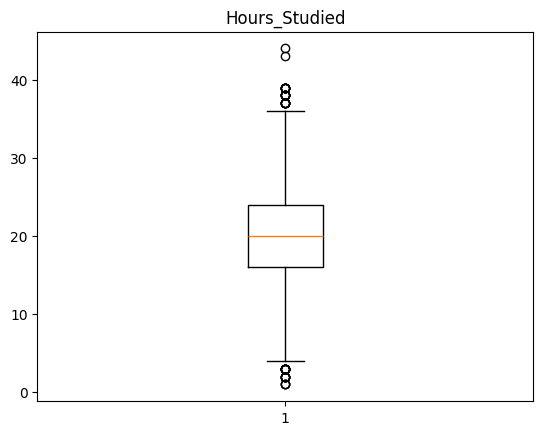

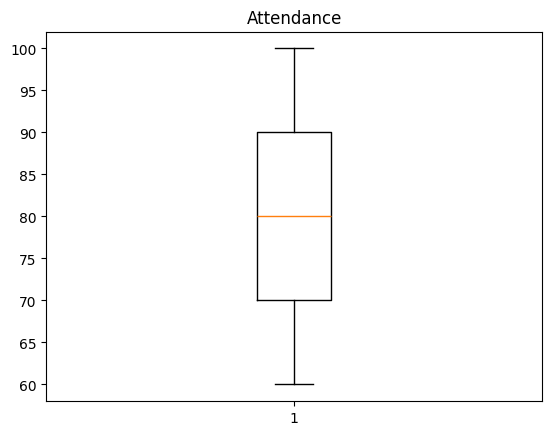

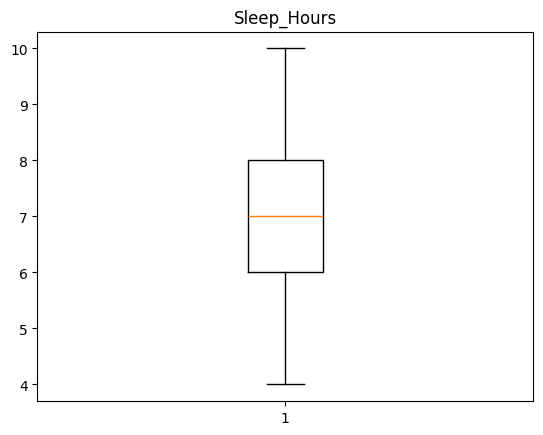

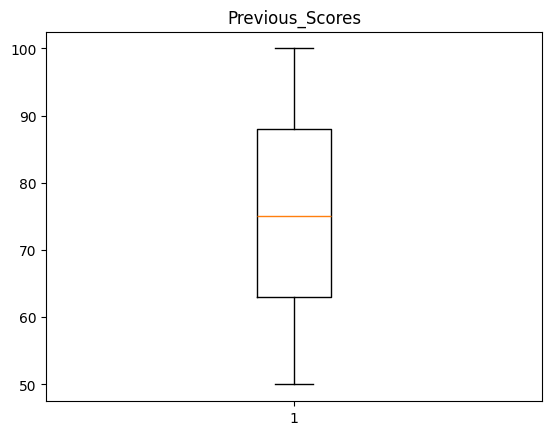

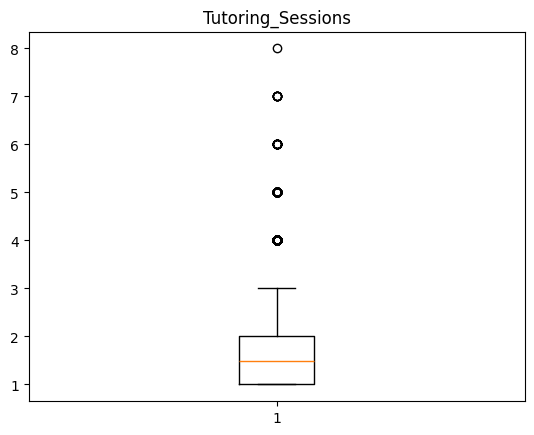

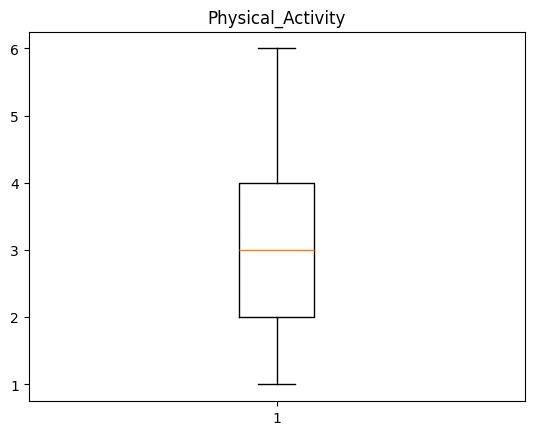

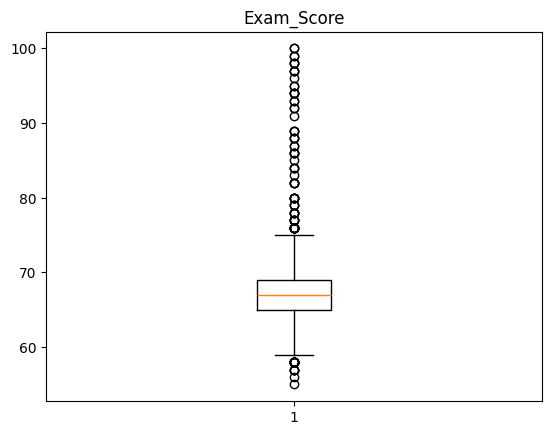

In [ ]:
cols_numeric=list(student.select_dtypes('number'))

for col in cols_numeric:
 plt.boxplot(student[col])
 plt.title(col)
 plt.show()



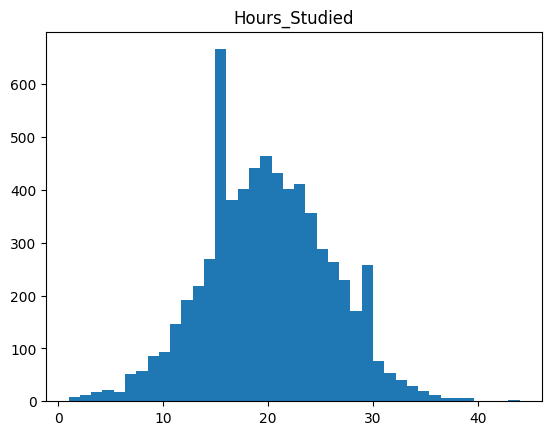

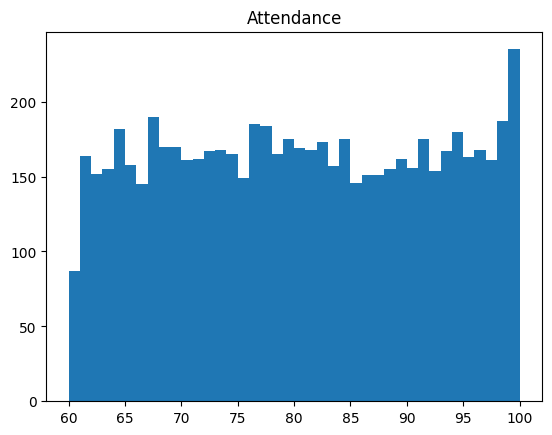

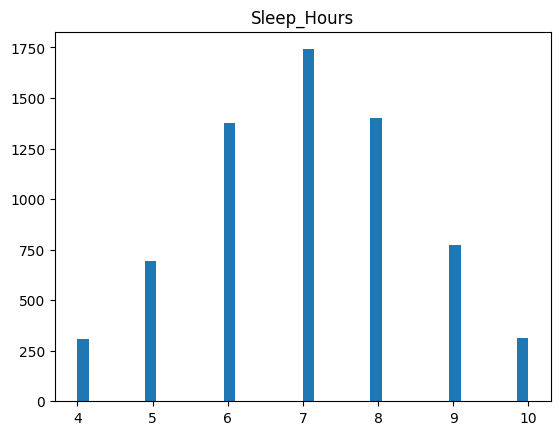

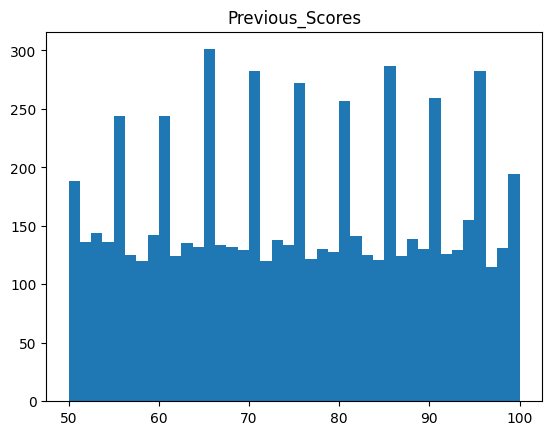

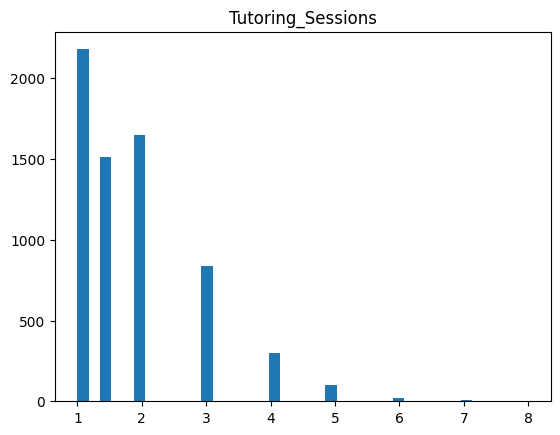

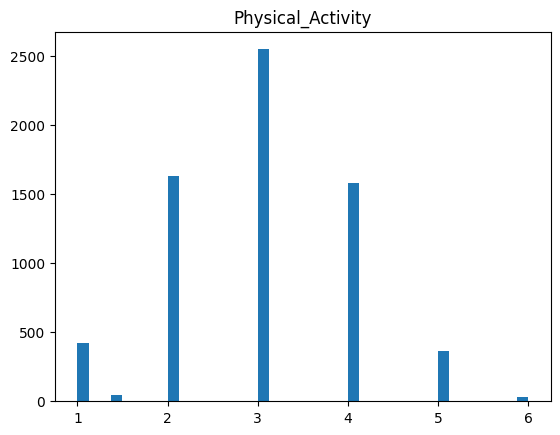

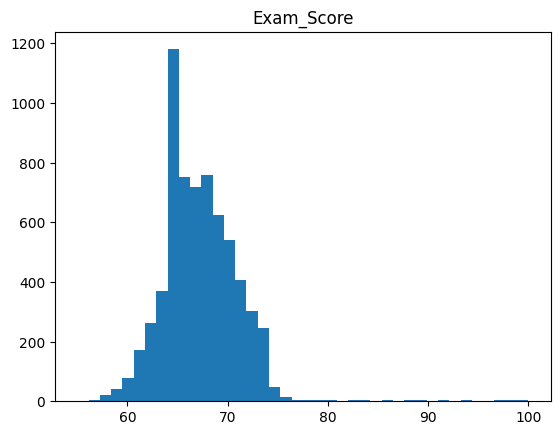

In [ ]:

for col in cols_numeric:
 plt.hist(student[col],bins=40)
 plt.title(col)
 plt.show()

In [ ]:
for col in cols_numeric:
  q1=student[col].quantile(0.25)
  q3=student[col].quantile(0.75)
  IQR=q3-q1
  lower_bound = max(0,q1 - 1.5 * IQR)
  upper_bound = q3 + 1.5 * IQR

  student=student[(student[col]>= lower_bound) & (student[col]<=upper_bound) ]




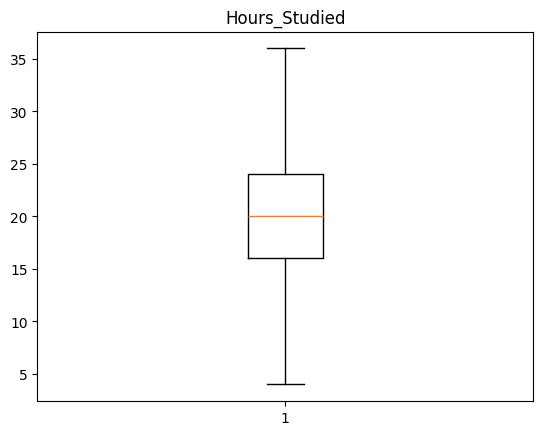

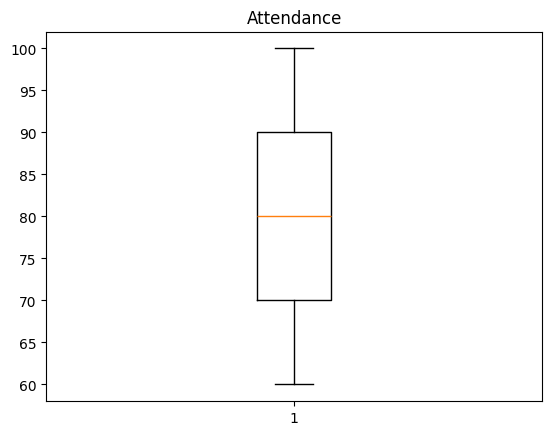

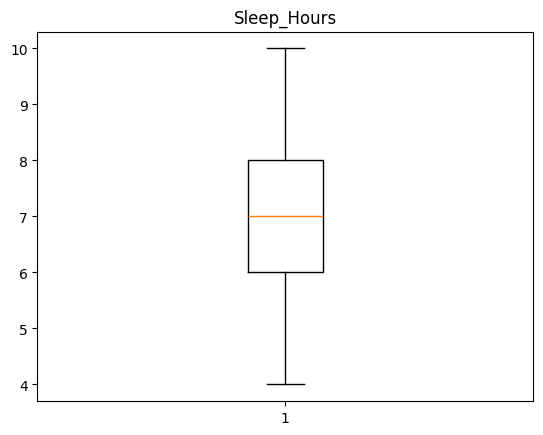

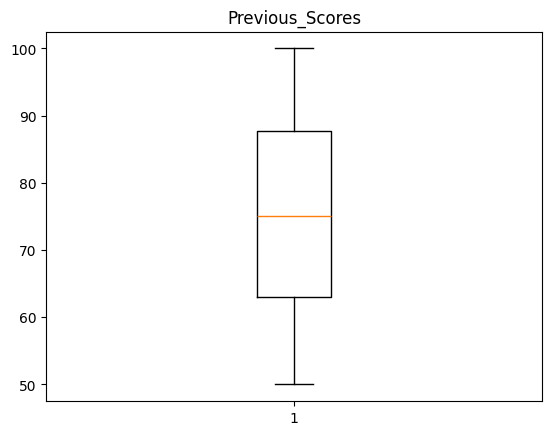

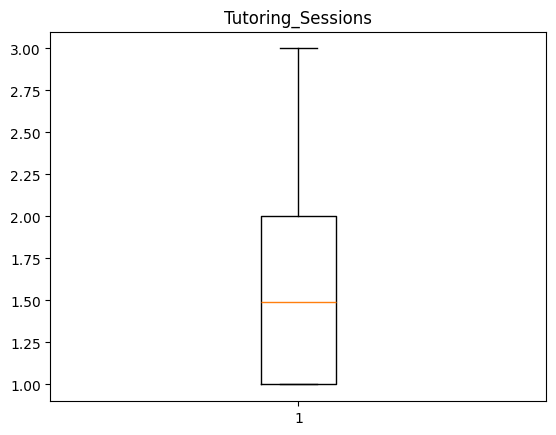

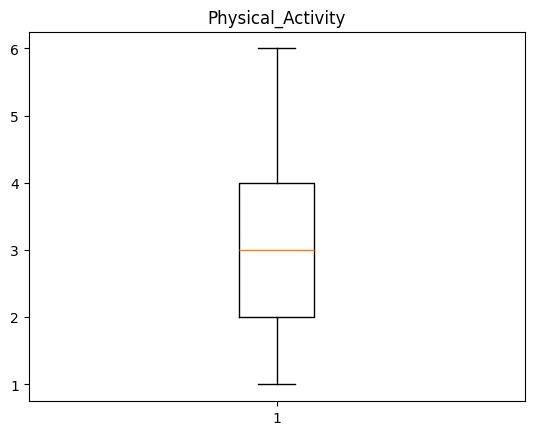

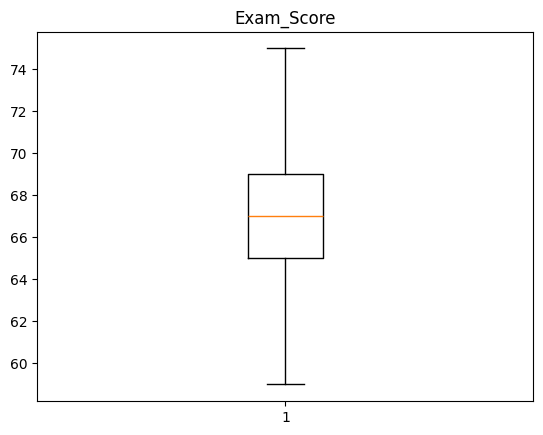

In [ ]:
for col in cols_numeric:
 plt.boxplot(student[col])
 plt.title(col)
 plt.show()

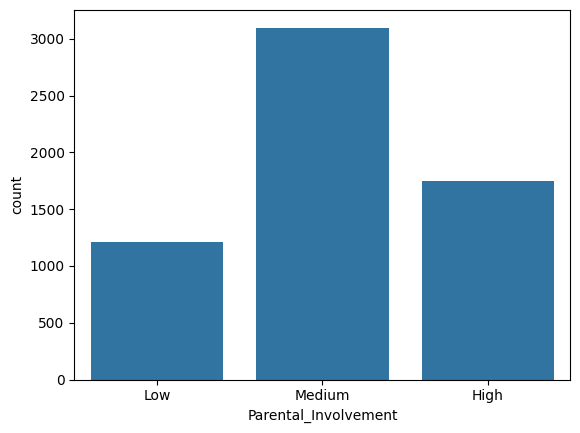

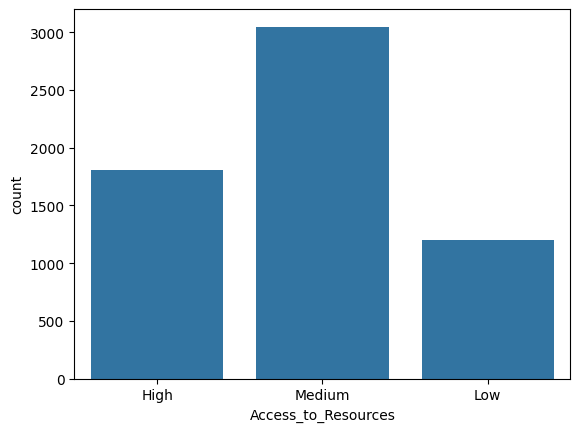

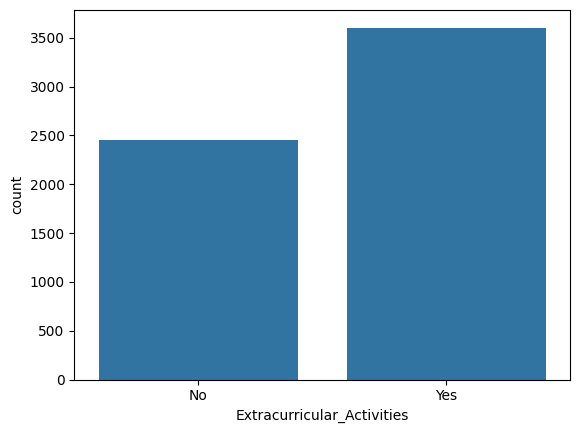

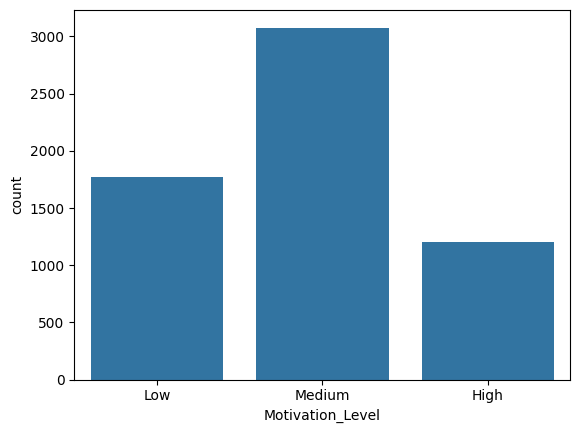

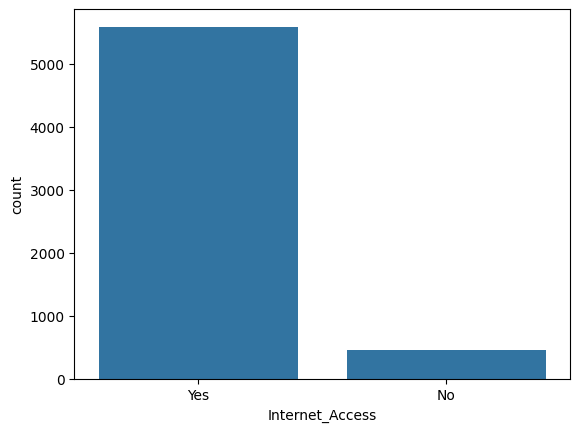

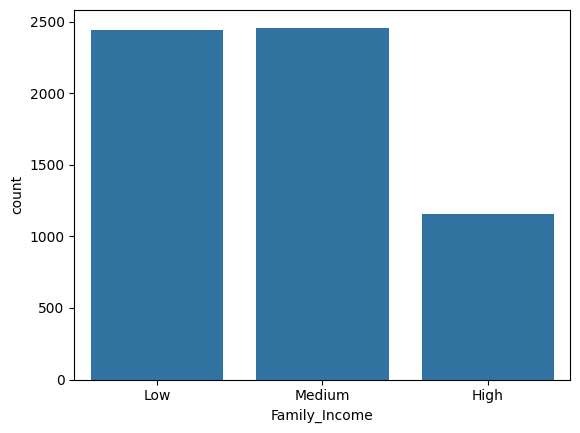

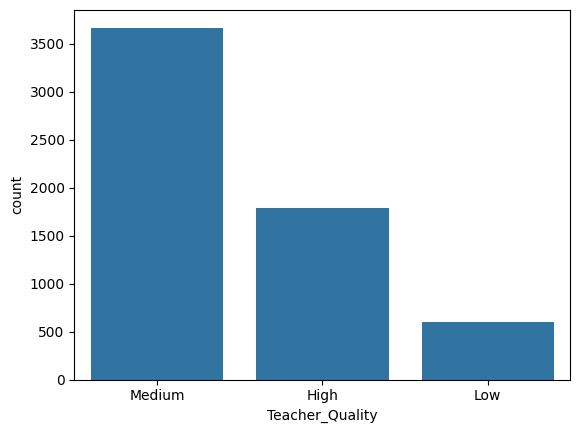

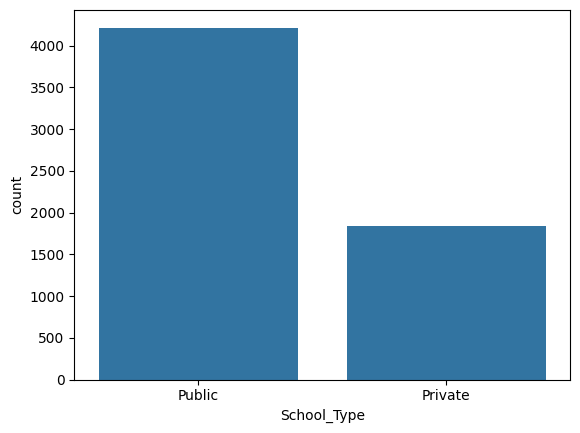

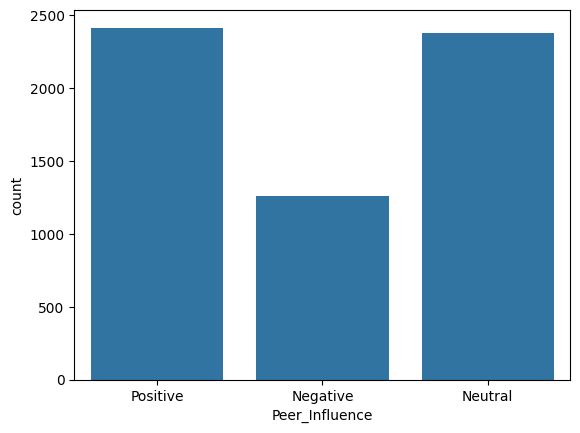

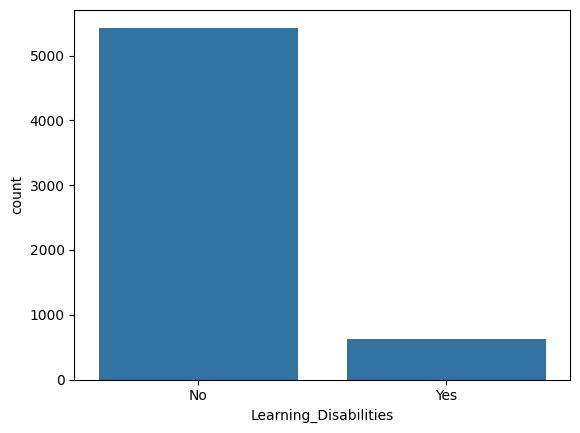

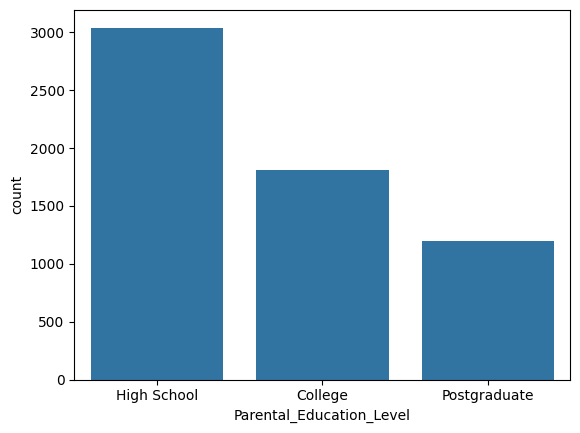

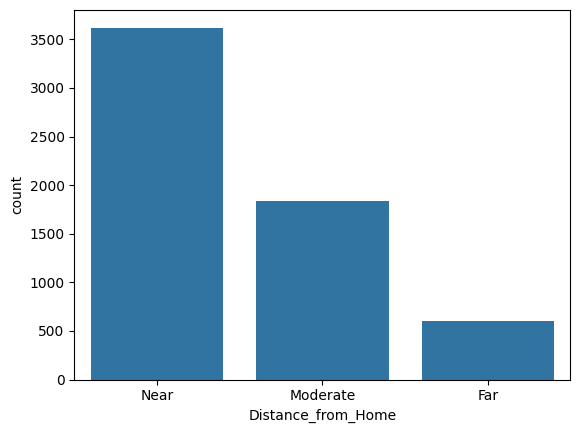

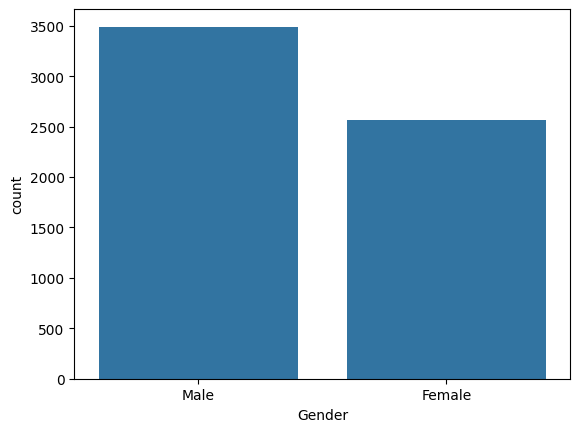

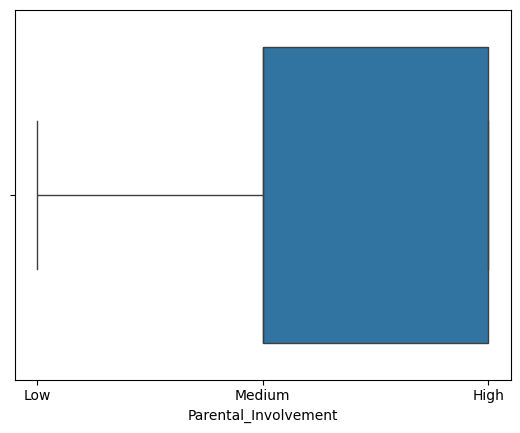

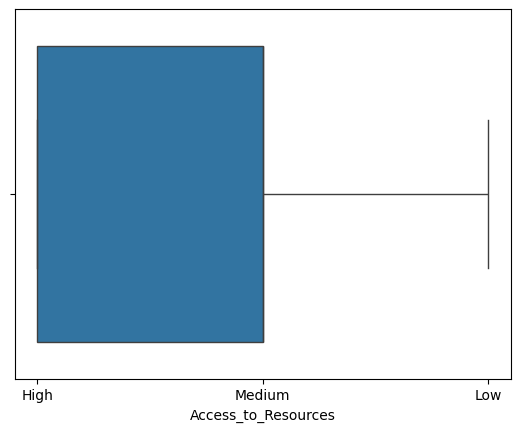

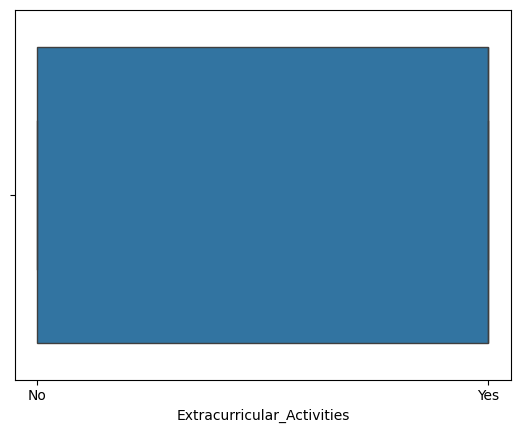

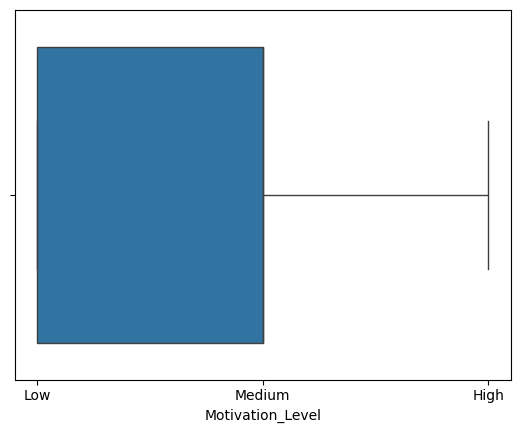

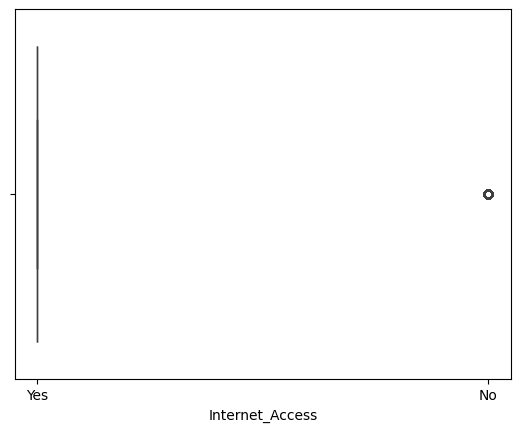

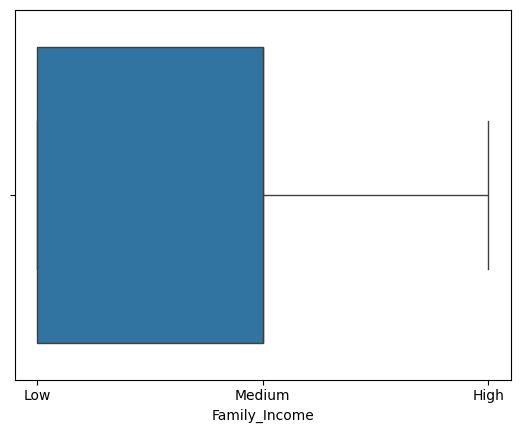

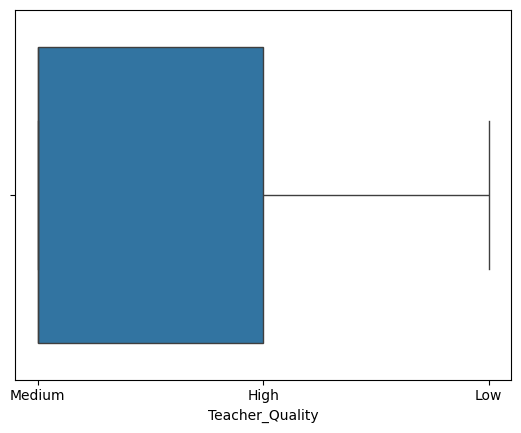

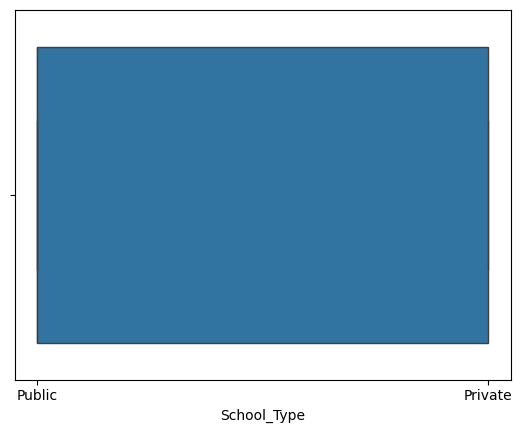

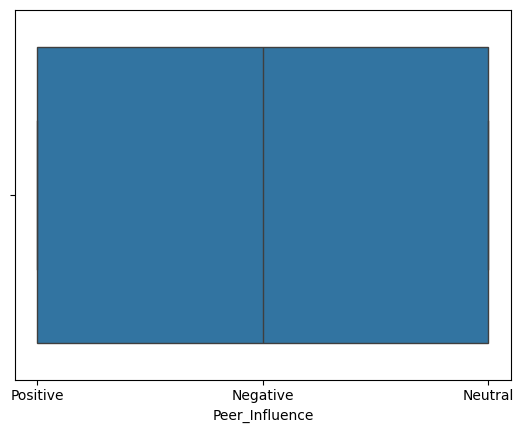

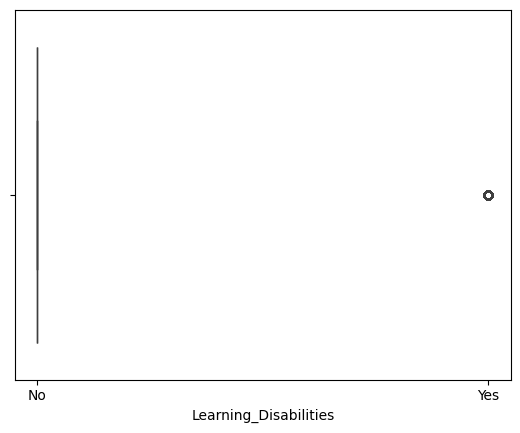

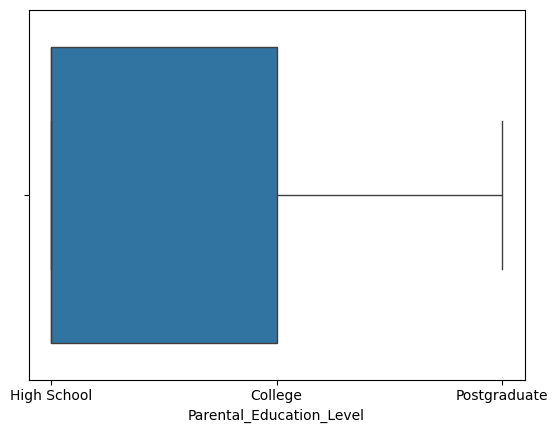

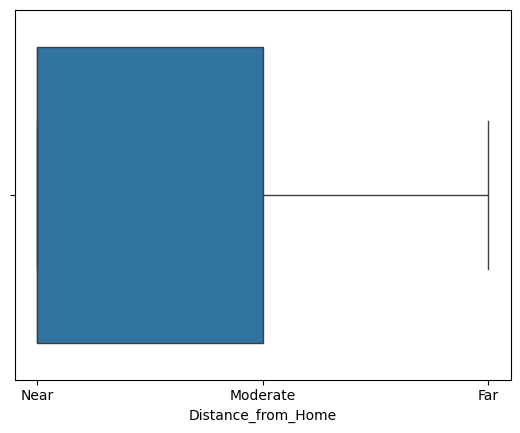

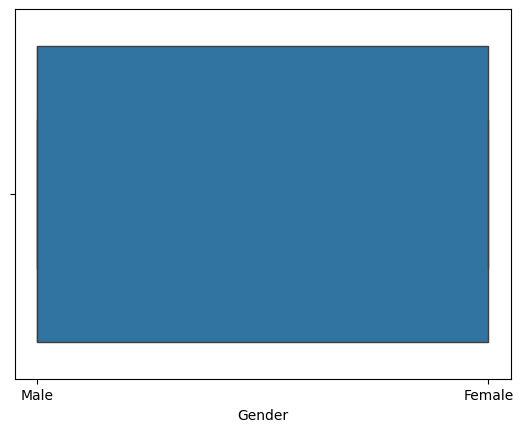

In [ ]:
cols_object=list(student.select_dtypes('object'))

for col in cols_object:
  sns.countplot(x=col,data=student)
  plt.show()

for col in cols_object:
  sns.boxplot(x=col,data=student)
  plt.show()



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cols_object:
  student[col]=le.fit_transform(student[col])

for col in cols_object:
  q1=student[col].quantile(0.25)
  q3=student[col].quantile(0.75)
  IQR=q3-q1
  lower_bound = max(0 , q1 - 1.5 * IQR )
  upper_bound = q3 + 1.5 * IQR
  student[col] = student[col].clip(lower_bound, upper_bound)



In [ ]:
student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,1.493719,1,2,1,2,3.0,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2.000000,2,2,1,0,4.0,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2.000000,2,2,1,1,4.0,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1.000000,2,2,1,0,4.0,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3.000000,2,0,1,1,4.0,0,0,2,0,70


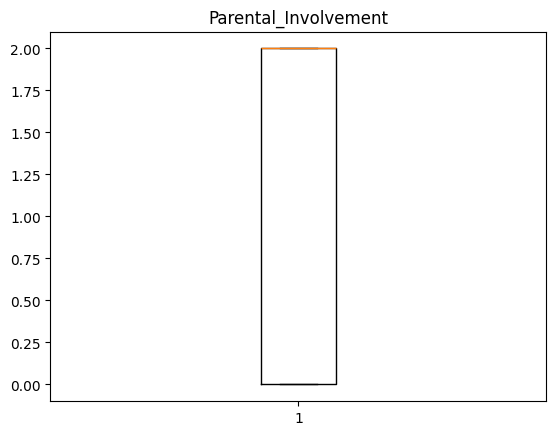

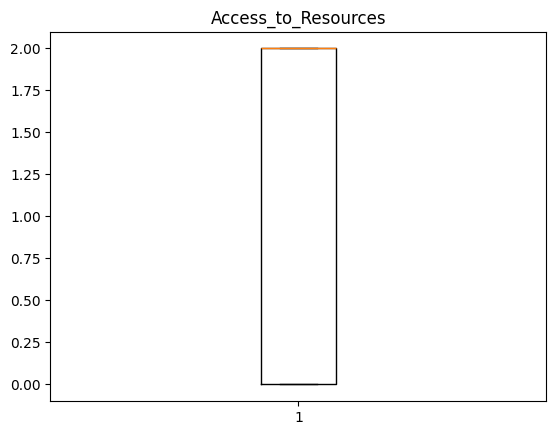

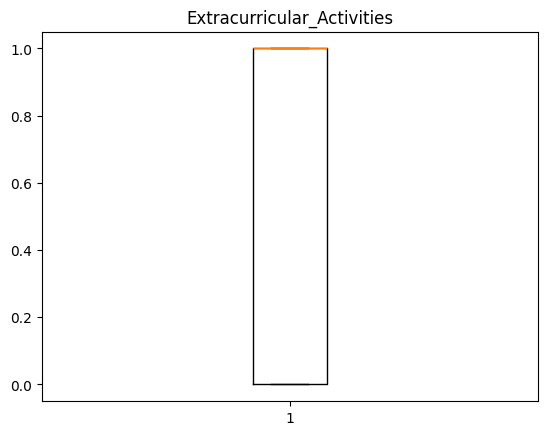

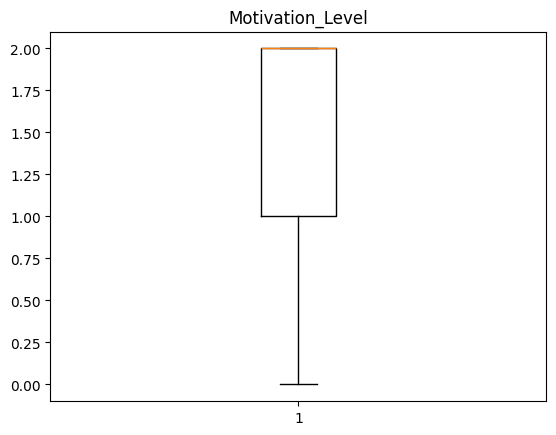

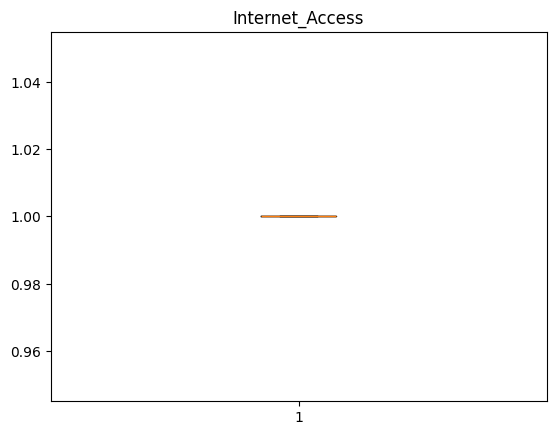

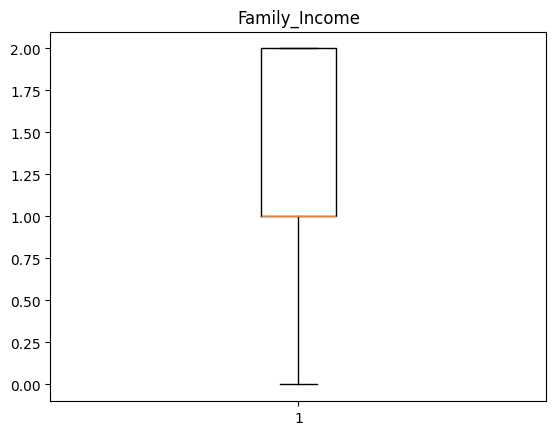

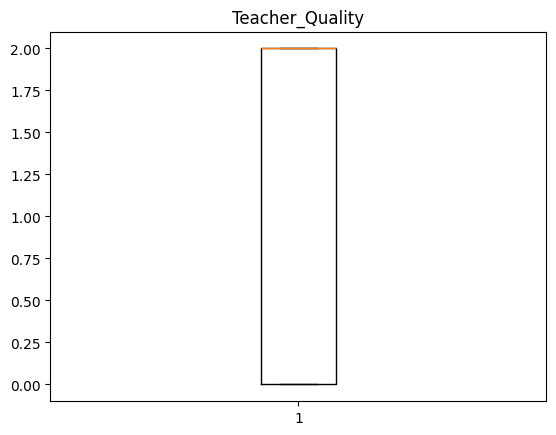

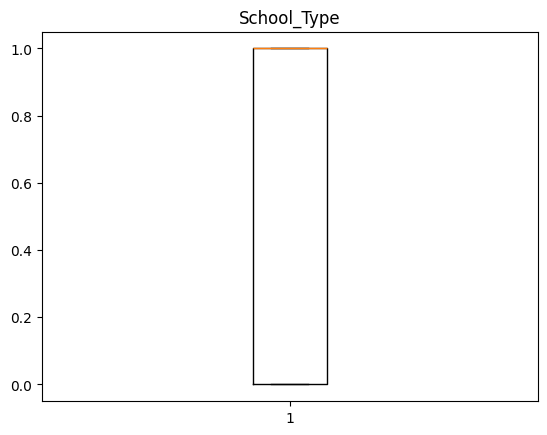

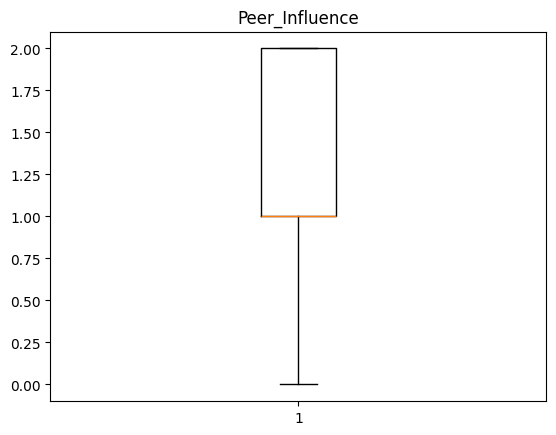

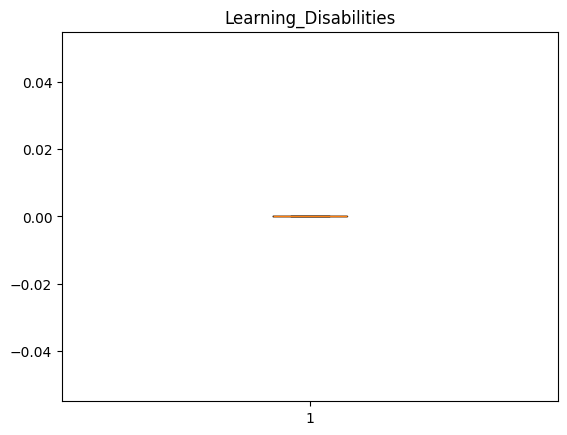

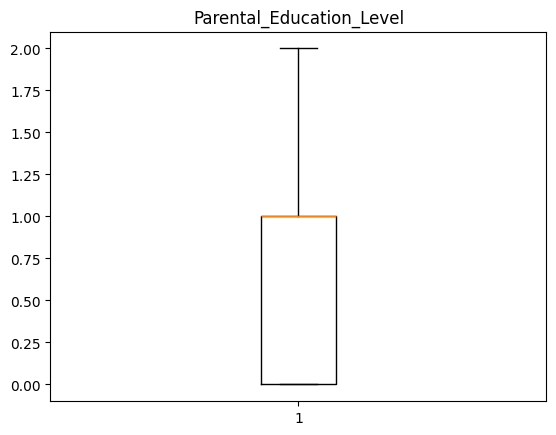

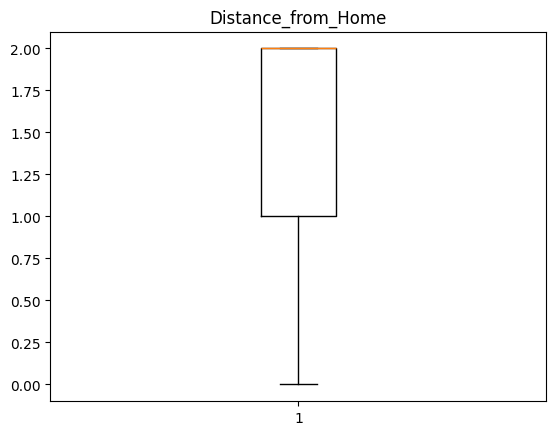

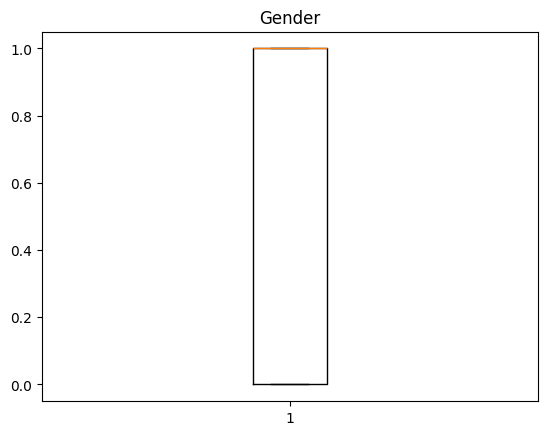

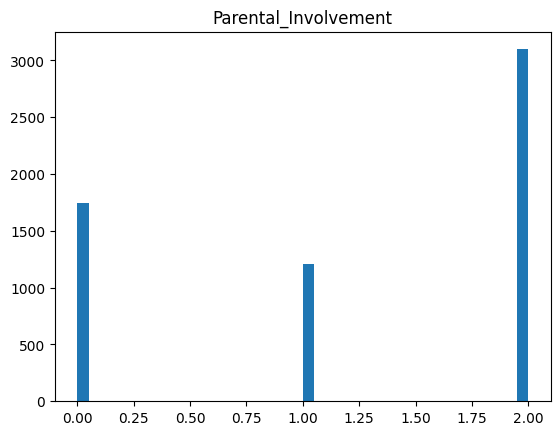

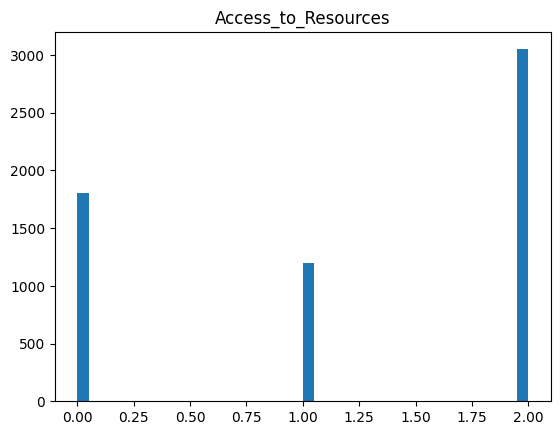

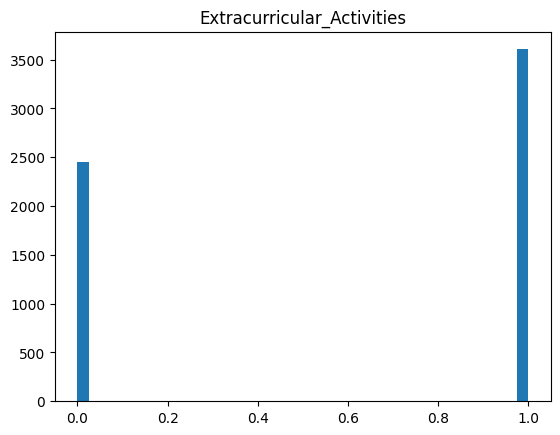

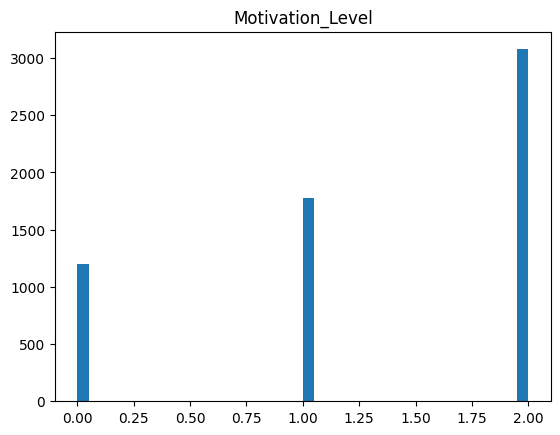

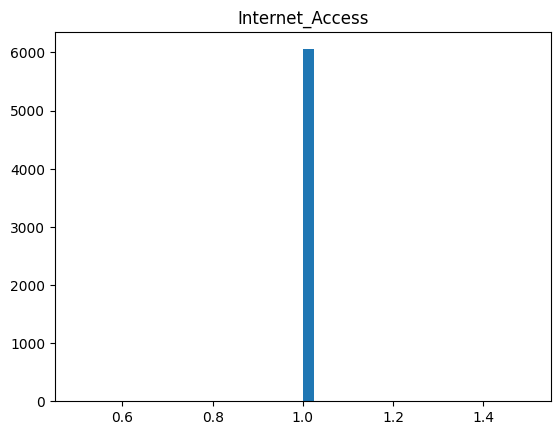

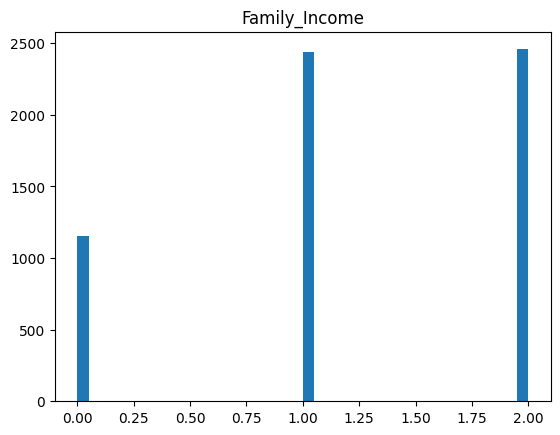

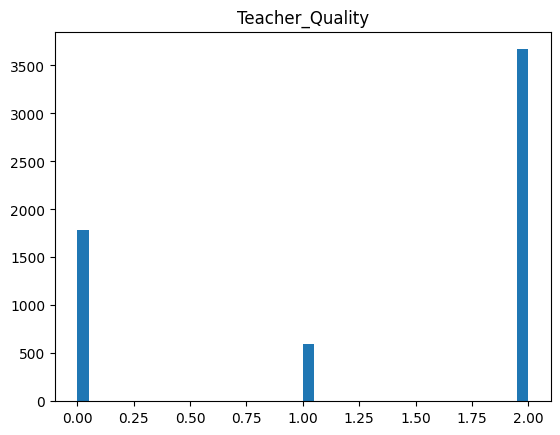

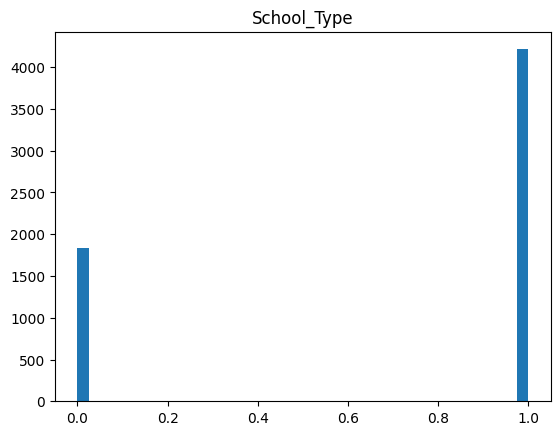

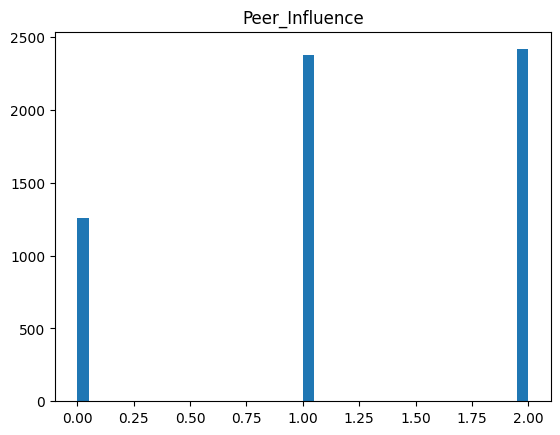

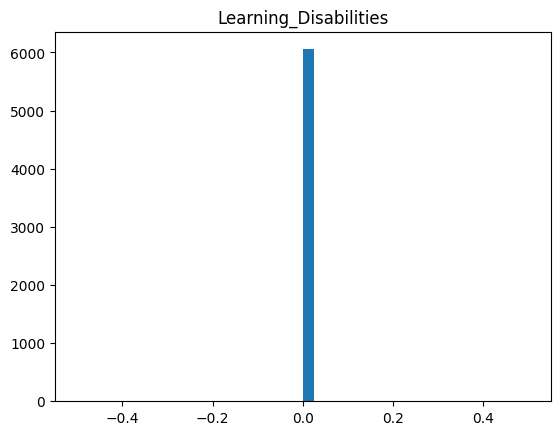

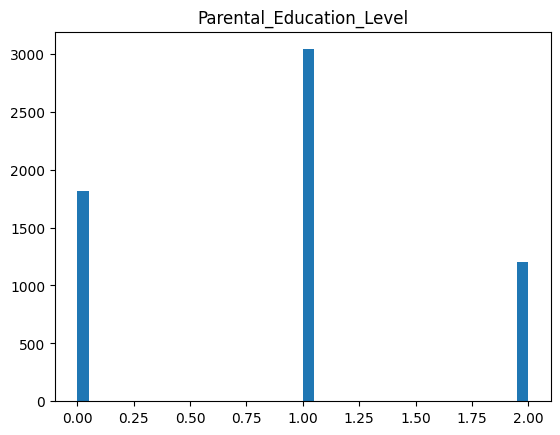

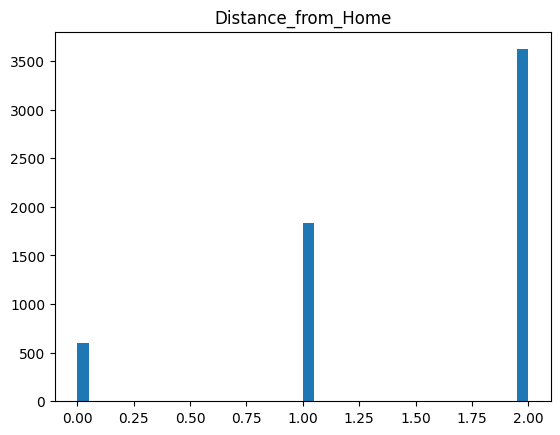

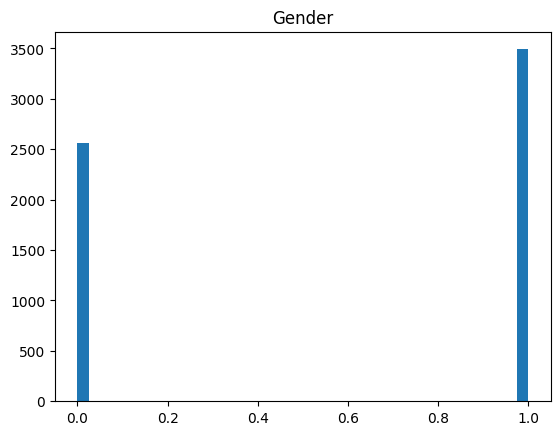

In [ ]:
for col in cols_object:
  plt.boxplot(student[col])
  plt.title(col)
  plt.show()

for col in cols_object:
  plt.hist(student[col],bins=40)
  plt.title(col)
  plt.show()


In [ ]:

  student.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6054 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6054 non-null   int64  
 1   Attendance                  6054 non-null   int64  
 2   Parental_Involvement        6054 non-null   int64  
 3   Access_to_Resources         6054 non-null   int64  
 4   Extracurricular_Activities  6054 non-null   int64  
 5   Sleep_Hours                 6054 non-null   int64  
 6   Previous_Scores             6054 non-null   int64  
 7   Motivation_Level            6054 non-null   int64  
 8   Internet_Access             6054 non-null   int64  
 9   Tutoring_Sessions           6054 non-null   float64
 10  Family_Income               6054 non-null   int64  
 11  Teacher_Quality             6054 non-null   int64  
 12  School_Type                 6054 non-null   int64  
 13  Peer_Influence              6054 non-n

In [ ]:
(student['Internet_Access']==1).sum()

np.int64(6054)

In [ ]:
(student['Learning_Disabilities']==0).sum()

np.int64(6054)

In [ ]:
student.drop(columns=['Internet_Access','Learning_Disabilities'],inplace=True)

In [ ]:

student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1.493719,1,2,1,2,3.0,1,2,1,67
1,19,64,1,2,0,8,59,1,2.000000,2,2,1,0,4.0,0,1,0,61
2,24,98,2,2,1,7,91,2,2.000000,2,2,1,1,4.0,2,2,1,74
3,29,89,1,2,1,8,98,2,1.000000,2,2,1,0,4.0,1,1,1,71
4,19,92,2,2,1,6,65,2,3.000000,2,0,1,1,4.0,0,2,0,70


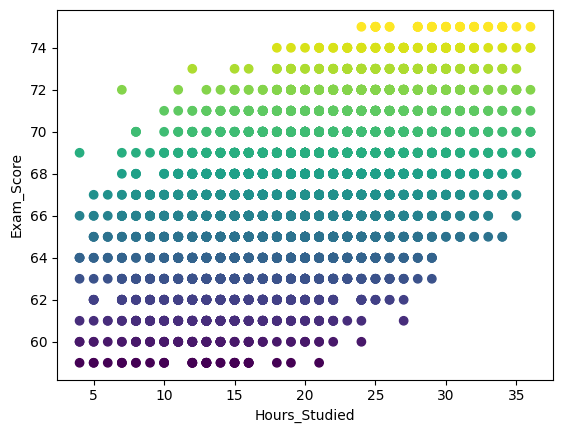

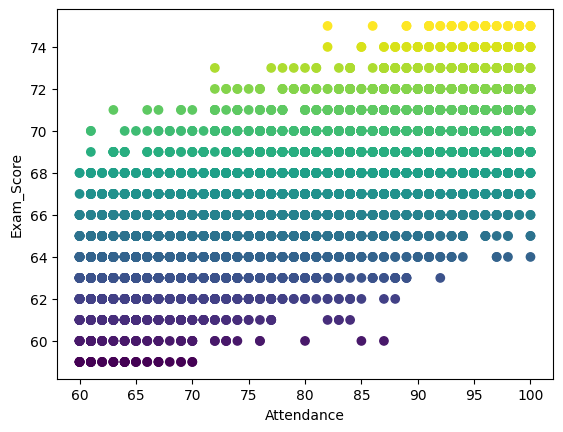

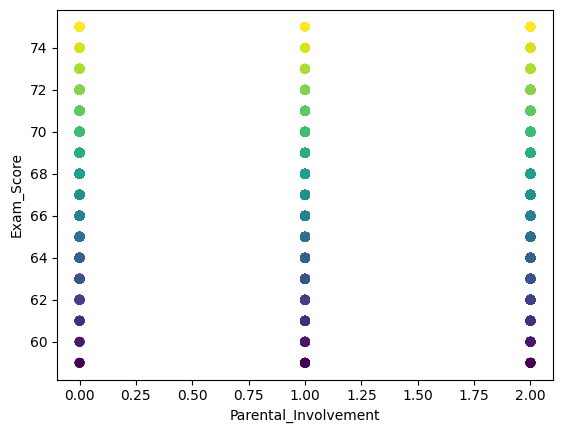

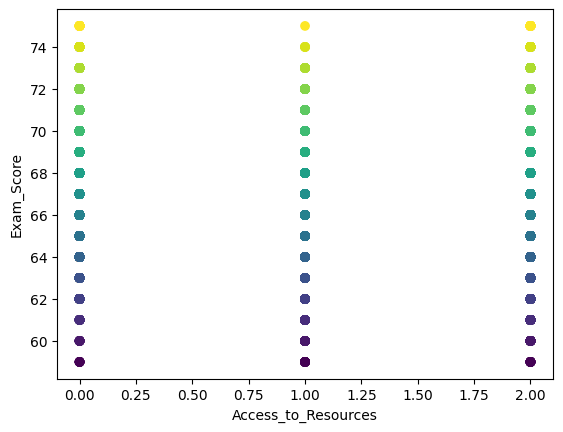

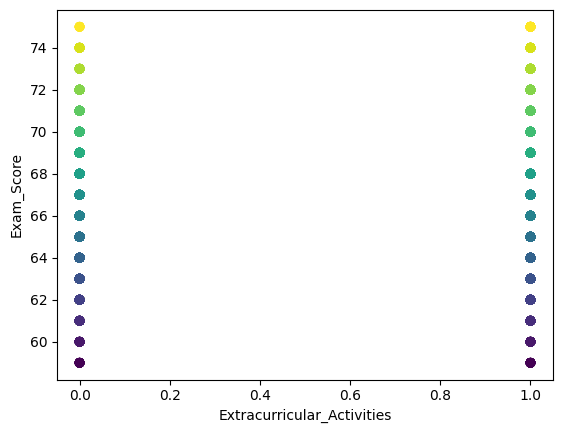

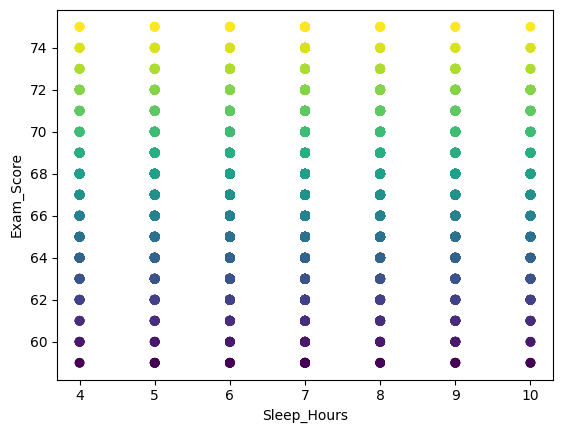

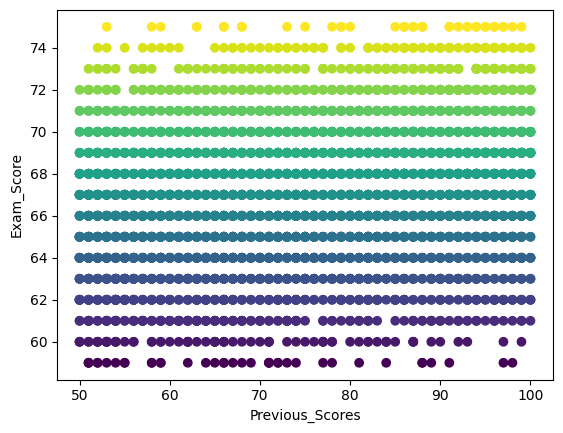

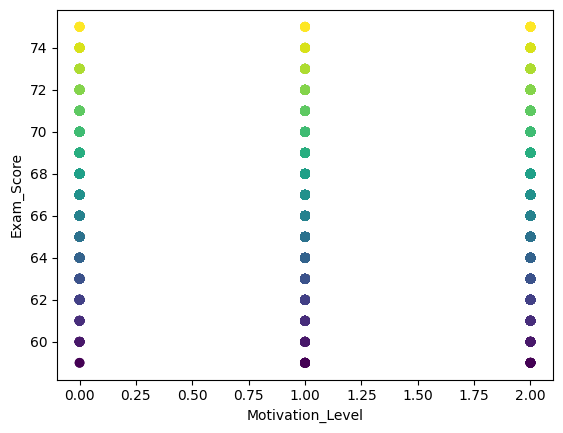

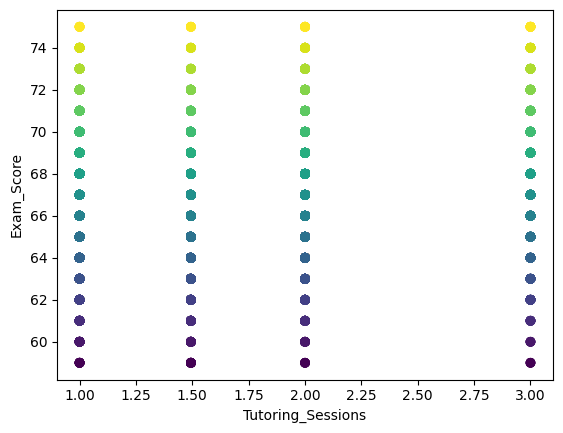

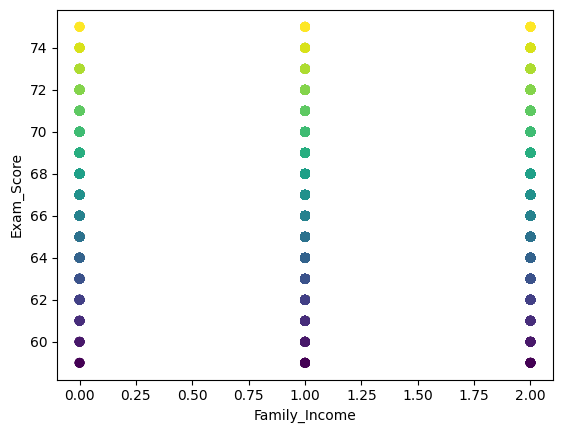

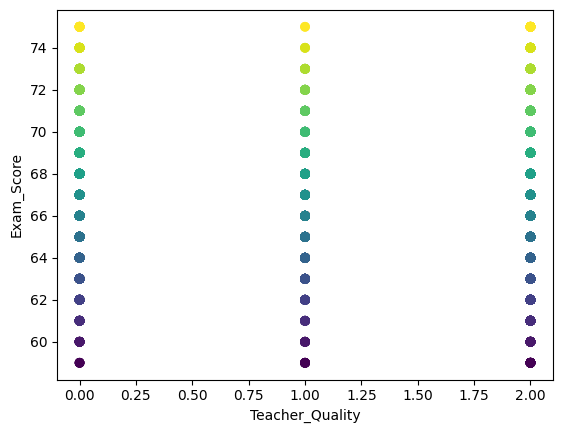

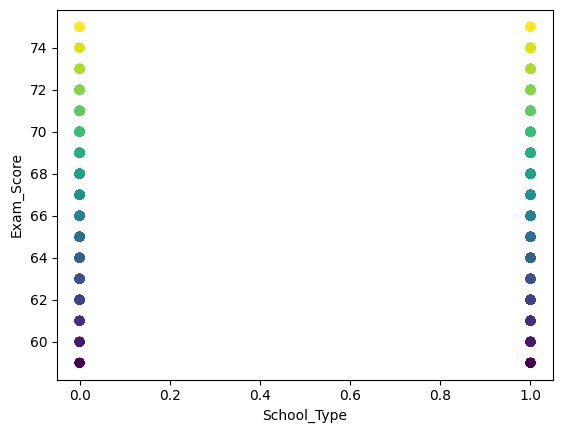

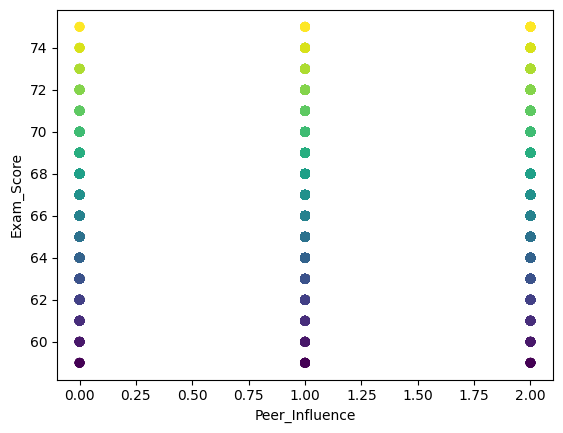

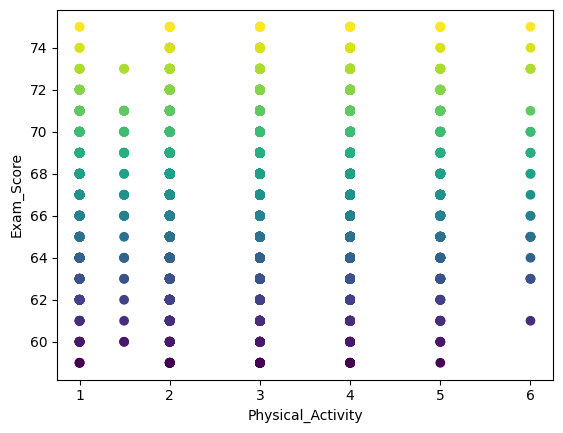

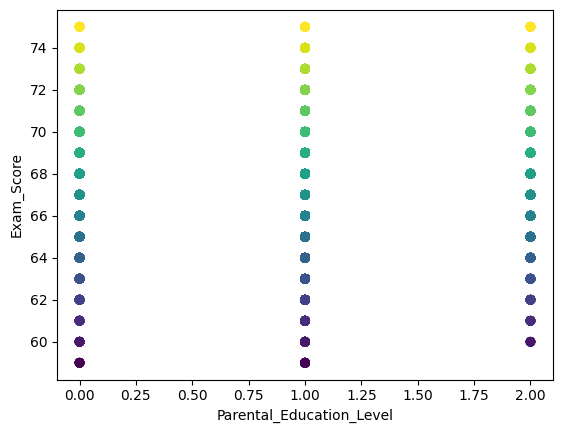

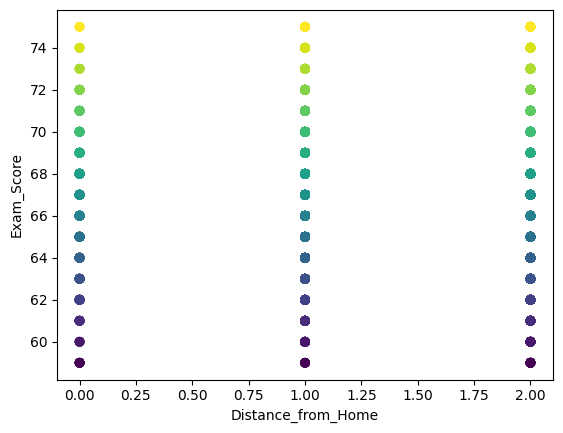

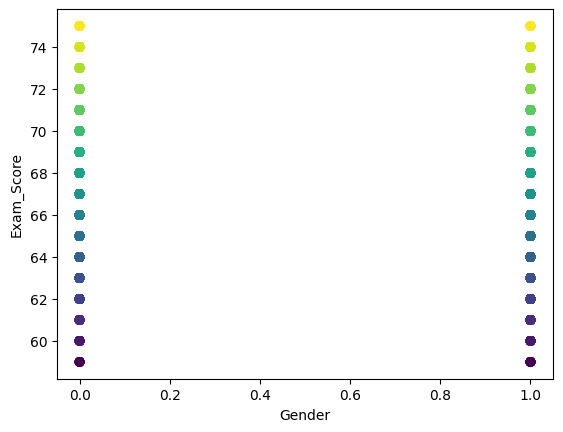

In [ ]:
X=student.drop(columns=['Exam_Score'])
y=student['Exam_Score']
target_name='Exam_Score'
feature_names=X.columns

for col in feature_names:
   plt.scatter(student[col],y,c=y,marker='o')
   plt.xlabel(col)
   plt.ylabel(target_name)
   plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20,shuffle=True)




In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
y_train=scaler.fit_transform(y_train.values.reshape(-1,1))
y_test=scaler.transform(y_test.values.reshape(-1,1))



In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)



In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f'MSE:{mse}')
print(f'MAE:{mae}')
print(f'r2_score:{r2}')



MSE:0.14233524477072046
MAE:0.3094039568819126
r2_score:0.8502963574443535


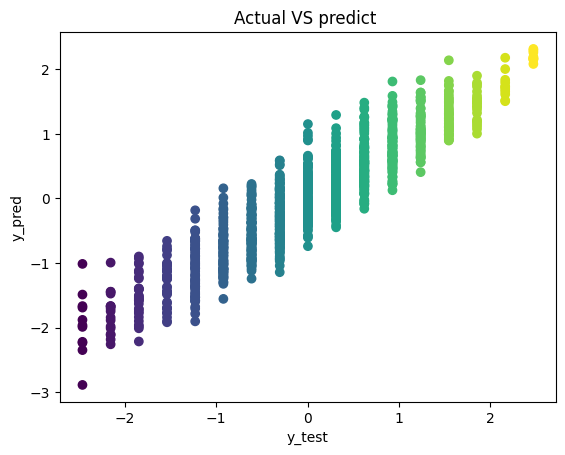

In [ ]:

plt.scatter(y_test,y_pred,marker='o',c=y_test)
plt.title('Actual VS predict ')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()